In [24]:
import os
import glob
import numpy as np
import pandas as pd

# Safe division to avoid divide-by-zero issues
def safe_divide(a, b):
    return a / b if b != 0 else np.nan

# Folder containing all your trade result CSVs
trades_folder = 'all_trades'
pattern = os.path.join(trades_folder, "All_Trades_Window_*_SL_*.csv")

summary_rows = []

for file in glob.glob(pattern):
    filename = os.path.basename(file)
    parts = filename.replace(".csv", "").split("_")
    window = int(parts[3])
    sl_mult = float(parts[5])
    
    df = pd.read_csv(file)
    if df.empty:
        print(f'window = {window} and sl =  {sl_mult} file not found')
        continue

    total_trades = len(df)
    win_trades = (df['PnL'] > 0).sum()
    win_rate = win_trades / total_trades * 100
    total_pnl = df['PnL'].sum()
    avg_pnl = df['PnL'].mean()
    max_drawdown = (df['Cumulative PnL'].cummax() - df['Cumulative PnL']).max()
    avg_win = df.loc[df['PnL'] > 0, 'PnL'].mean()
    avg_loss = df.loc[df['PnL'] < 0, 'PnL'].mean()
    rr = abs(avg_win) / abs(avg_loss) if avg_loss != 0 else float('inf')
    avg_mae = df['MAE'].mean()
    max_mae = df['MAE'].min()
    avg_mfe = df['MFE'].mean()
    max_mfe = df['MFE'].max()
    winning_pnl = df.loc[df['PnL'] > 0, 'PnL'].sum()
    losing_pnl = df.loc[df['PnL'] < 0, 'PnL'].sum()
    efficiency = (df['PnL'] / df['MFE'].replace(0, float('nan'))) * 100
    avg_efficiency = efficiency.mean()
    total_units = df['Units'].sum()

    # Derived Metrics
    sharpe_like = safe_divide(avg_pnl, np.std([avg_win, abs(avg_loss)]))
    expectancy = (win_rate / 100) * avg_win + (1 - win_rate / 100) * avg_loss
    normalized_pnl = safe_divide(total_pnl, total_trades)
    pnl_per_unit = safe_divide(total_pnl, total_units)
    efficiency_ratio = safe_divide(avg_pnl, abs(avg_mae))

    # True Downside Deviation (for Sortino)
    downside_returns = df[df['PnL'] < 0]['PnL']
    downside_deviation = downside_returns.std() if not downside_returns.empty else 0
    sortino_ratio = safe_divide(avg_pnl, downside_deviation)

    summary_rows.append({
        'Window': window,
        'SL Multiplier': sl_mult,
        'Total Trades': total_trades,
        'Total Units': total_units,
        'Win Rate (%)': win_rate,
        'Total PnL': total_pnl,
        'Average PnL': avg_pnl,
        'Max Drawdown': max_drawdown,
        'Risk-Reward': rr,
        'Avg Win': avg_win,
        'Avg Loss': avg_loss,
        'Average MAE': avg_mae,
        'Max MAE': max_mae,
        'Average MFE': avg_mfe,
        'Max MFE': max_mfe,
        'Winning PnL': winning_pnl,
        'Losing PnL': losing_pnl,
        'Avg Trade Efficiency (%)': avg_efficiency,
        'Sharpe-like Ratio': sharpe_like,
        'Sortino Ratio': sortino_ratio,
        'Expectancy': expectancy,
        'Normalized PnL': normalized_pnl,
        'PnL per Unit': pnl_per_unit,
        'Efficiency Ratio': efficiency_ratio
    })

# Save to summary CSV
summary_df = pd.DataFrame(summary_rows)
summary_output_path = r"C:\Users\A\epat\Algo Project\Python-Projects\Parameters Comparison Summary\summary_results.csv"
summary_df.to_csv(summary_output_path, index=False)
print("✅ Final summary saved to summary_results.csv with all key metrics.")


✅ Final summary saved to summary_results.csv with all key metrics.


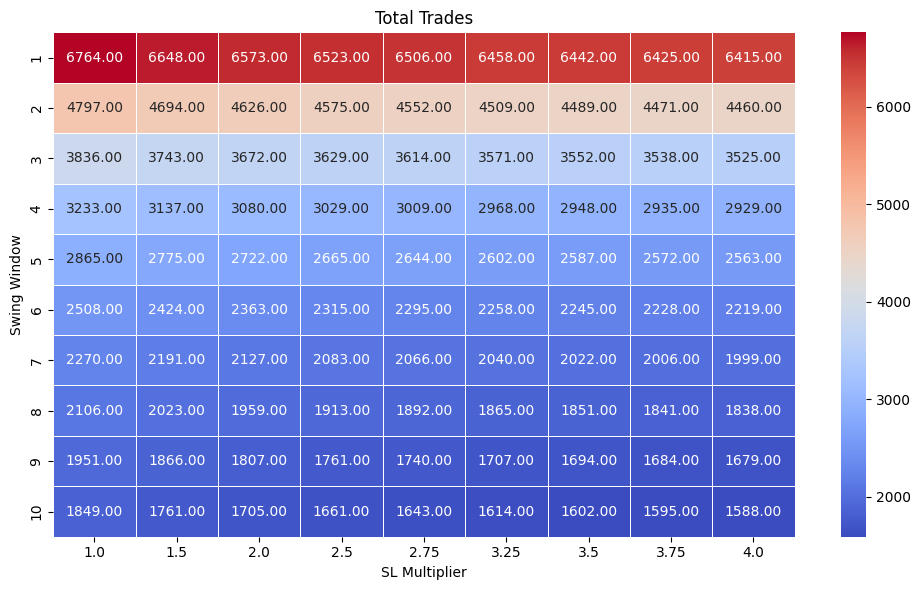

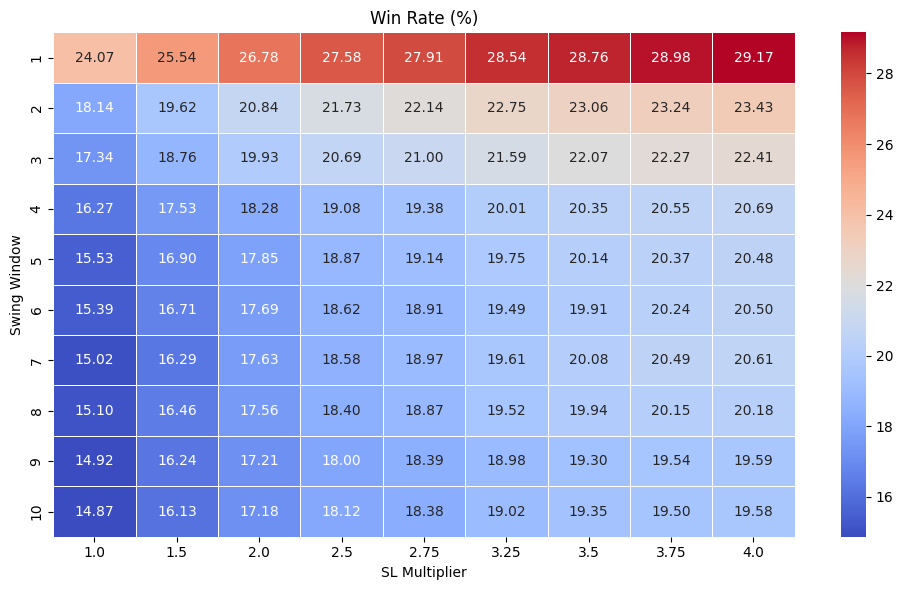

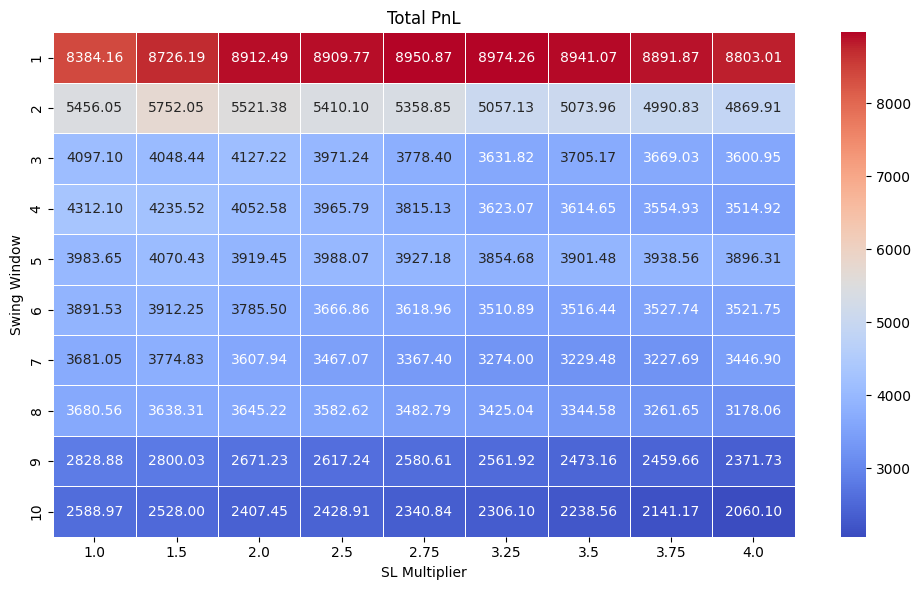

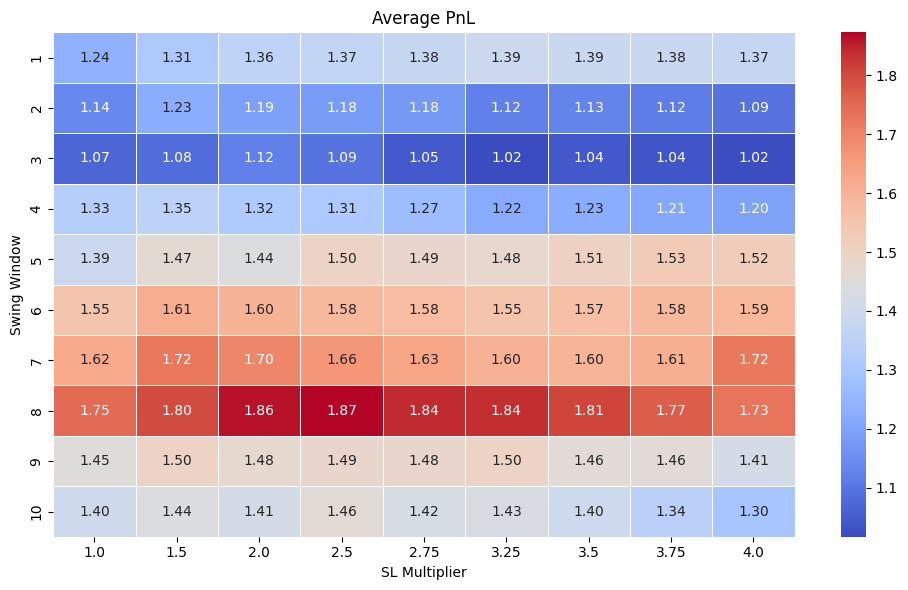

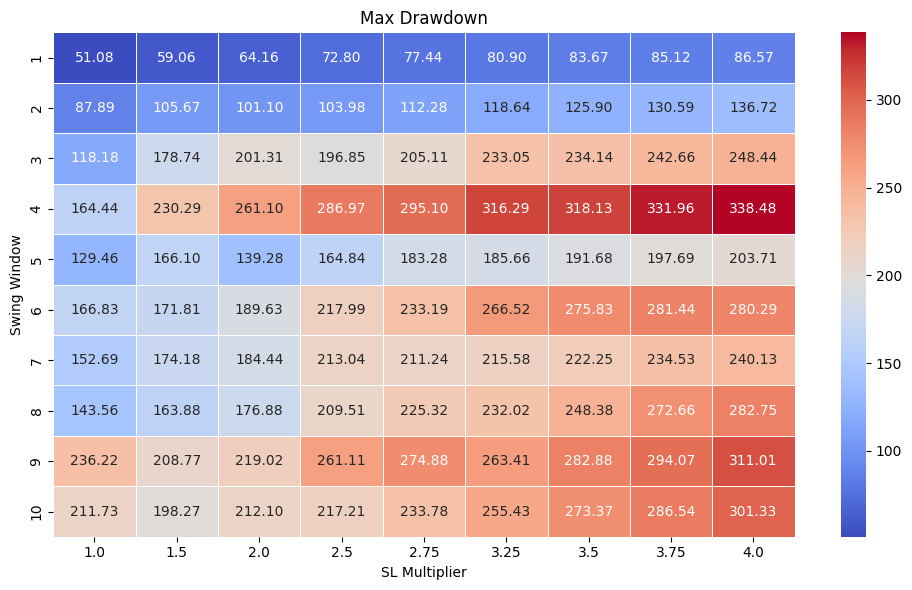

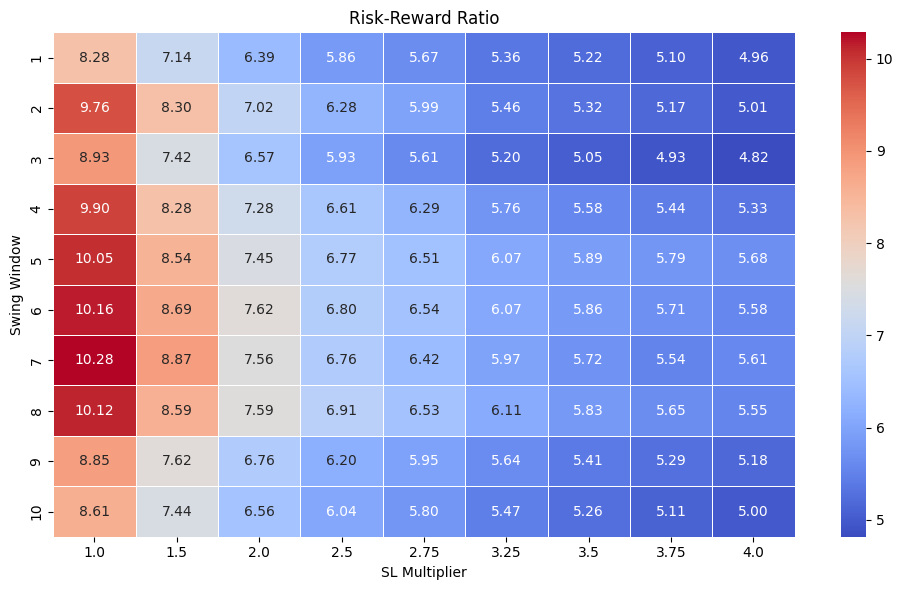

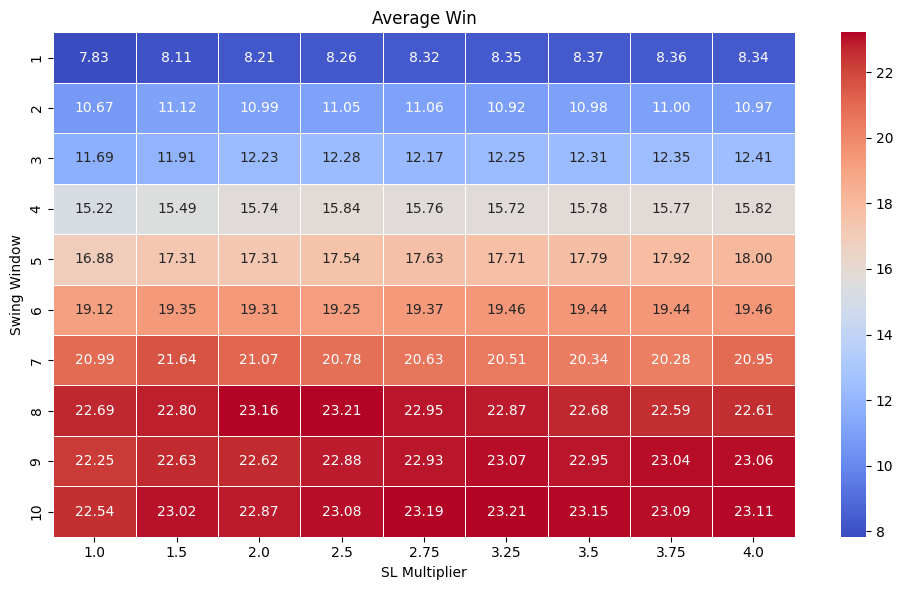

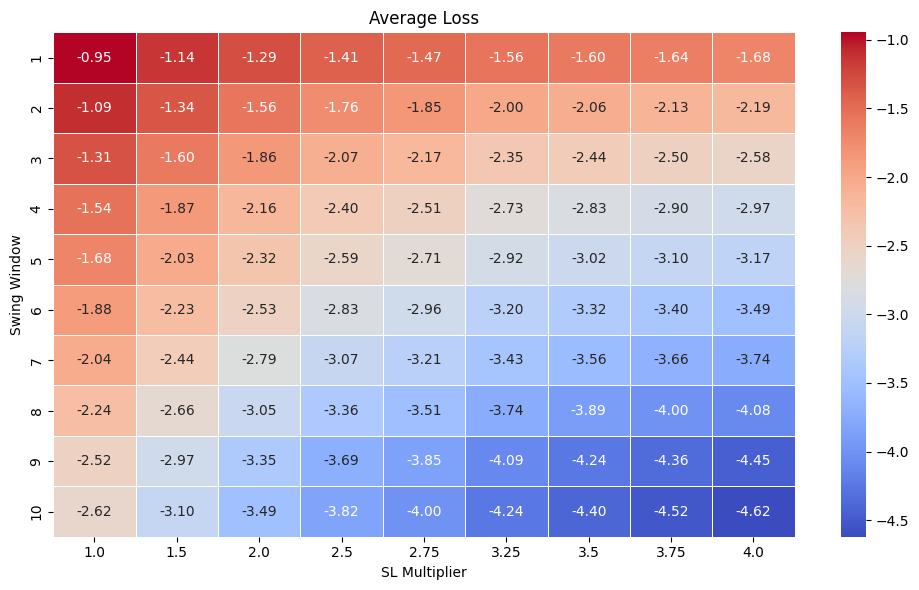

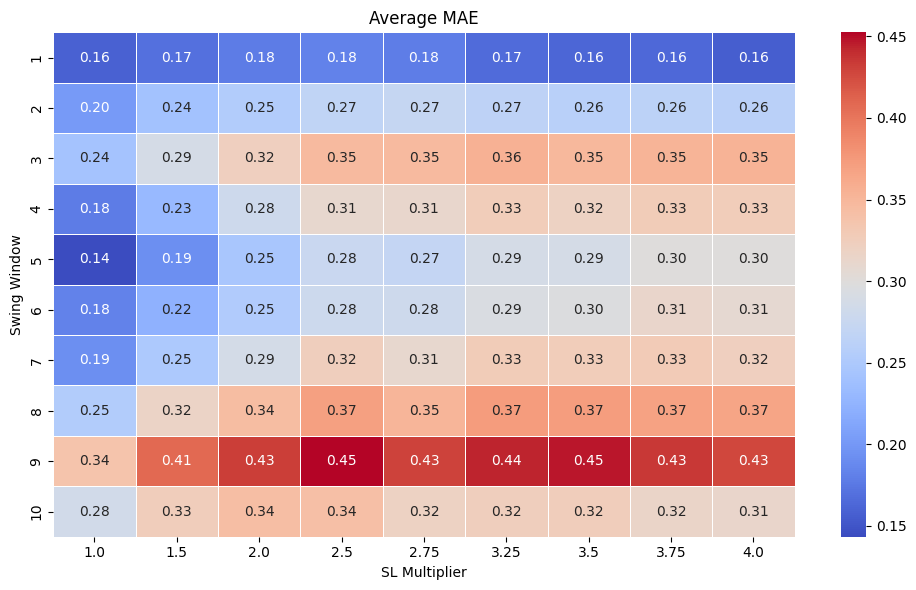

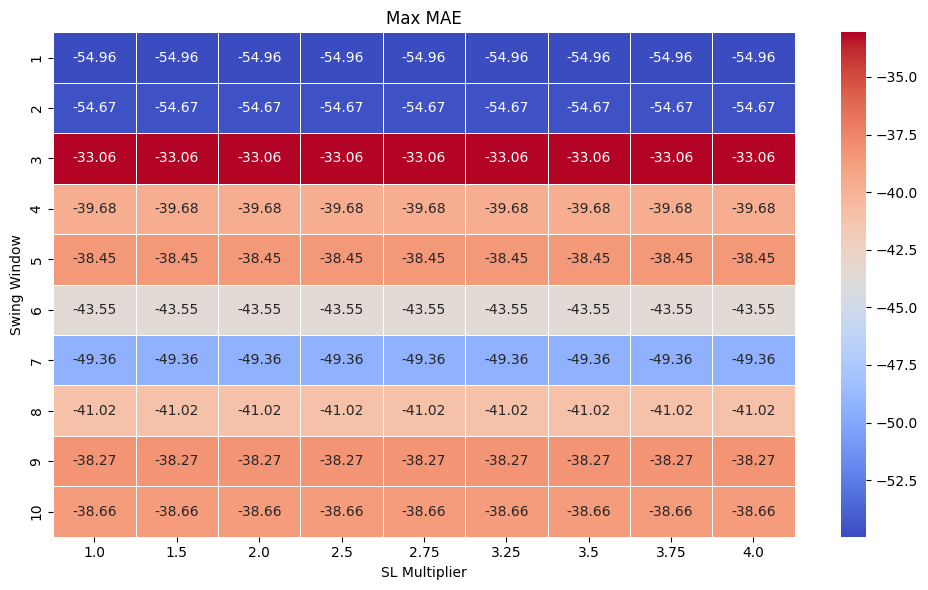

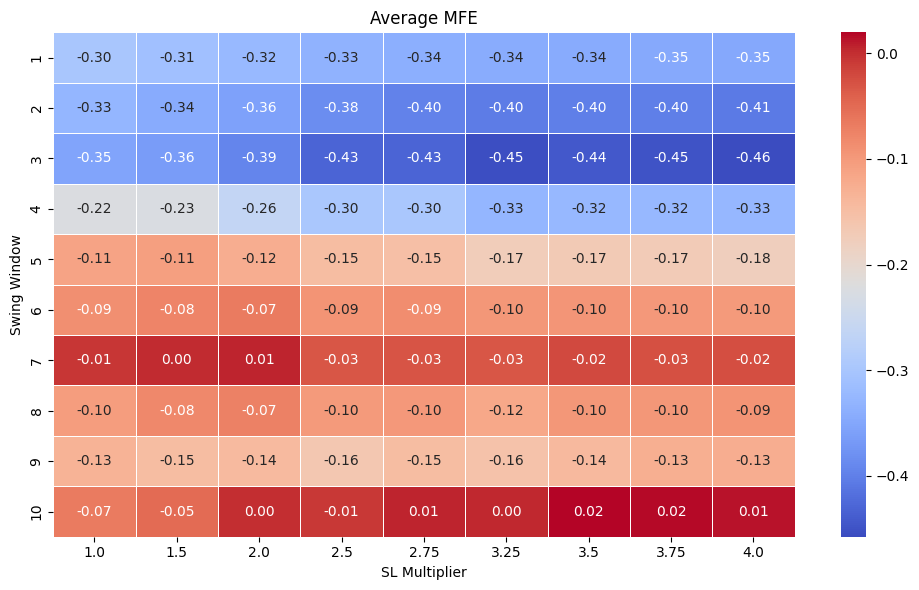

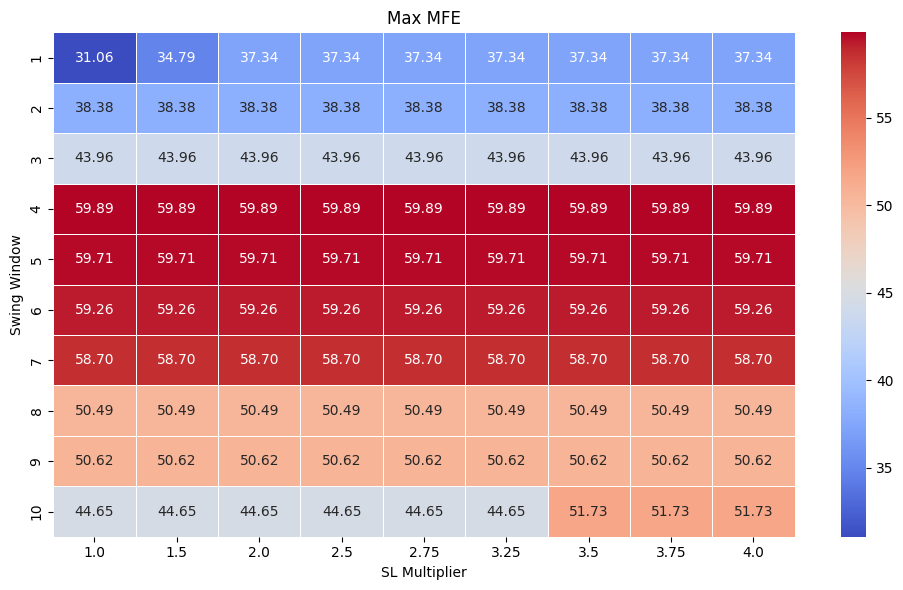

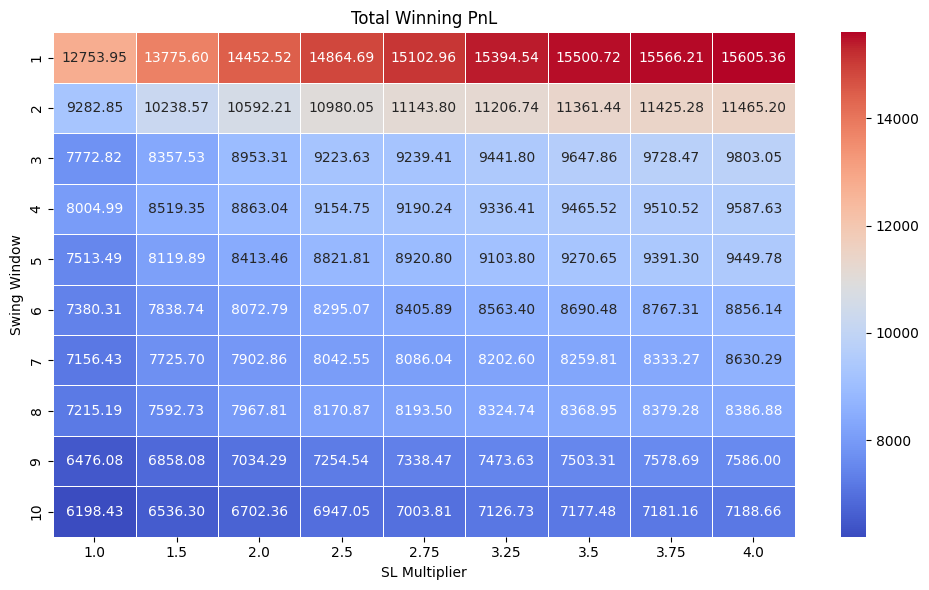

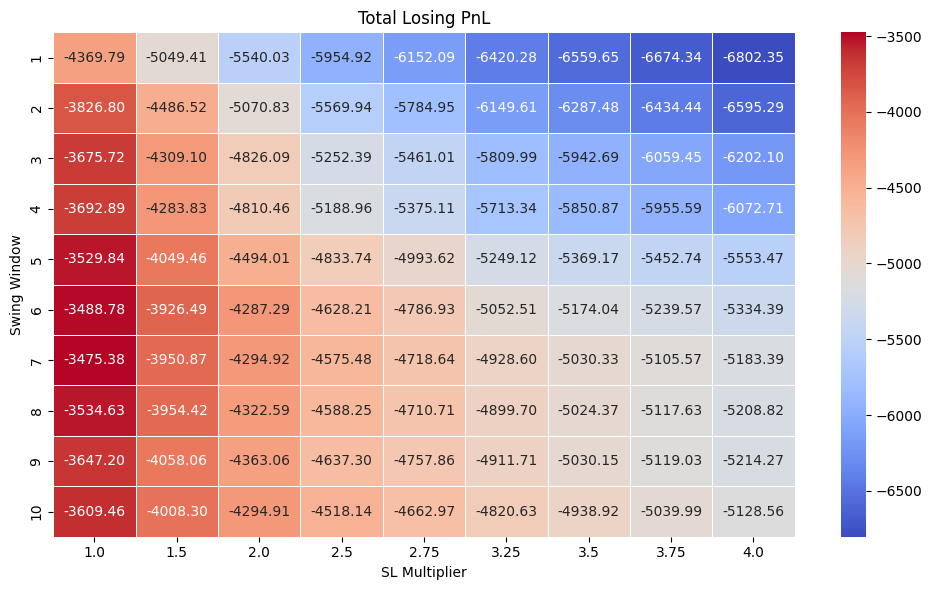

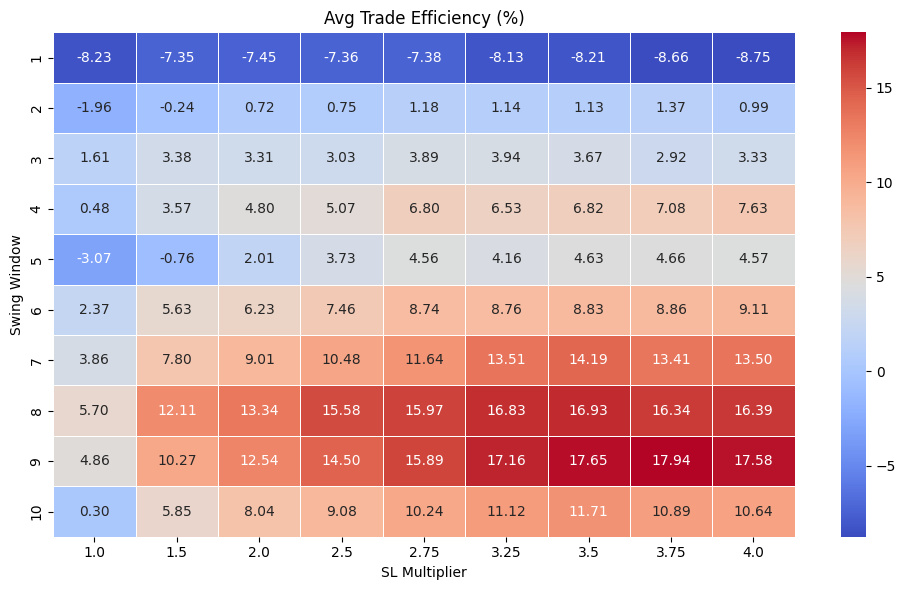

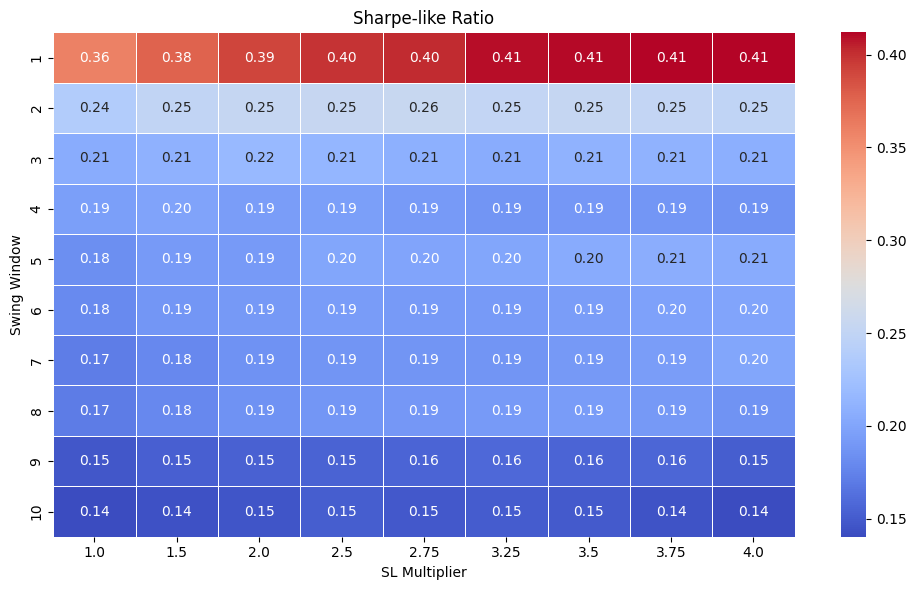

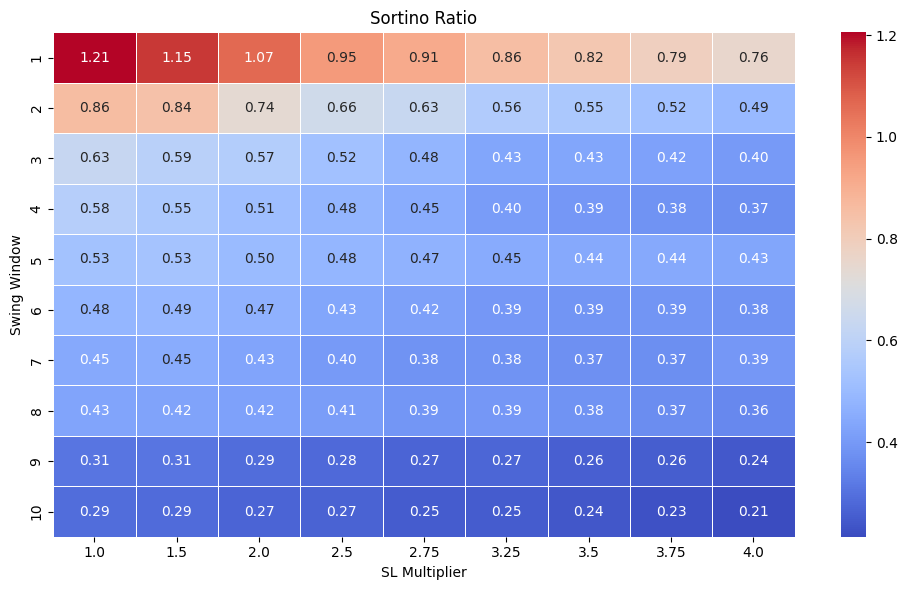

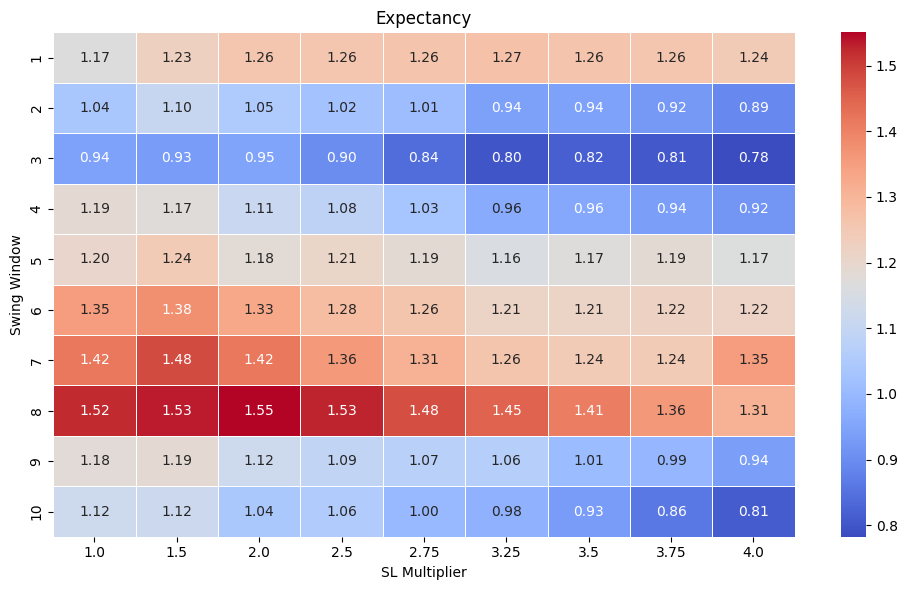

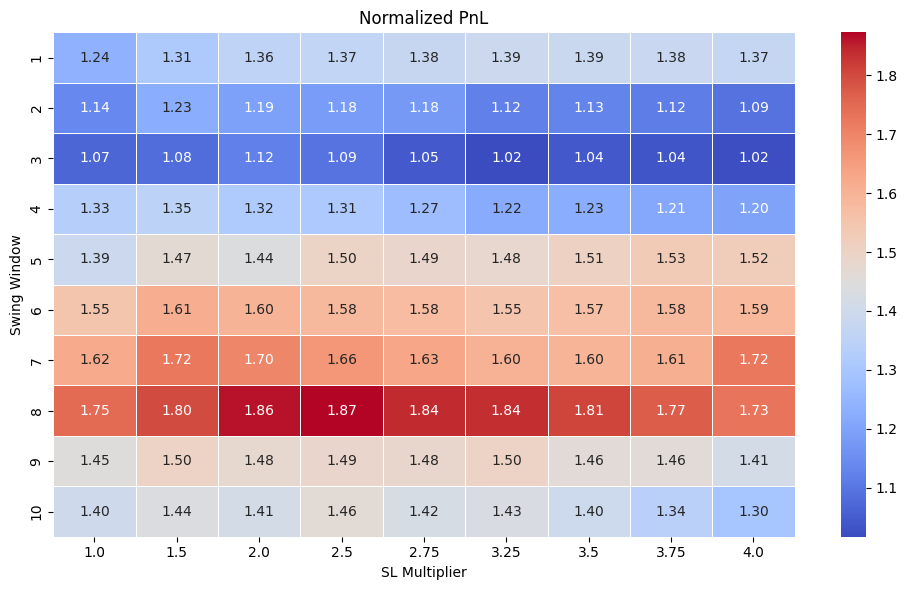

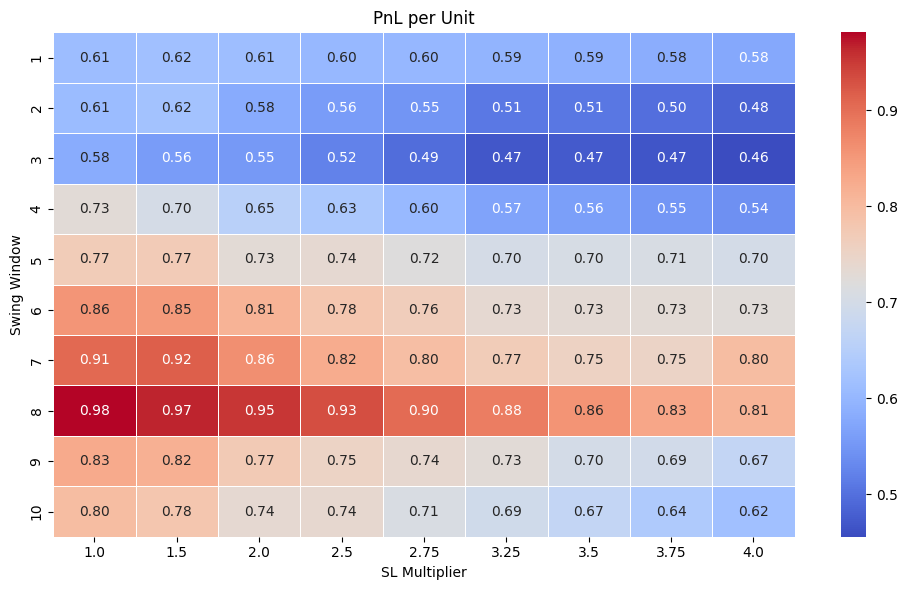

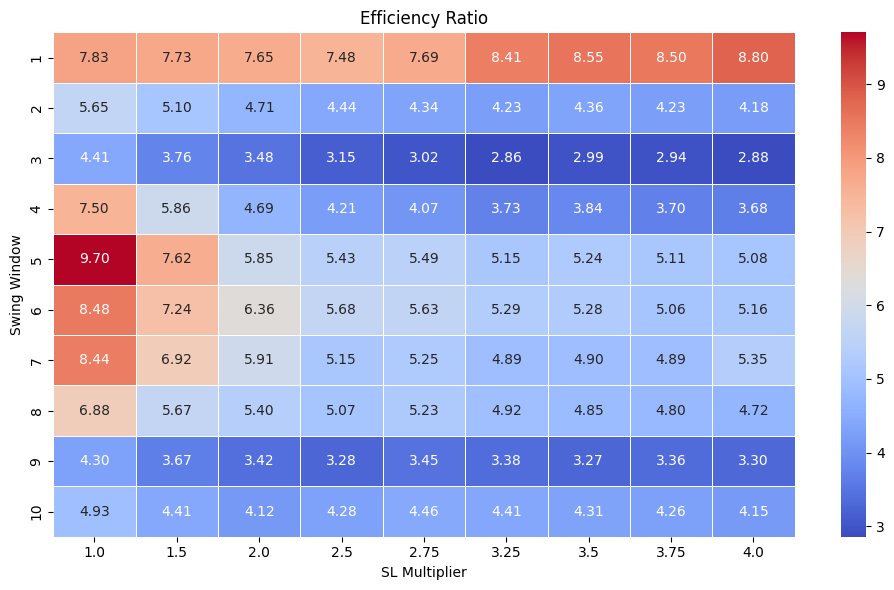

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the summary results
summary_path = r"Parameters Comparison Summary/summary_results.csv"
df = pd.read_csv(summary_path)

# Function to plot a heatmap for a given metric
def plot_heatmap(metric, title, cmap='coolwarm', fmt='.2f'):
    pivot = df.pivot(index="Window", columns="SL Multiplier", values=metric)
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap, linewidths=0.5)
    plt.title(title)
    plt.xlabel("SL Multiplier")
    plt.ylabel("Swing Window")
    plt.tight_layout()
    plt.show()

# List of metrics and corresponding titles
metrics_to_plot = [
    ("Total Trades", "Total Trades"),
    ("Win Rate (%)", "Win Rate (%)"),
    ("Total PnL", "Total PnL"),
    ("Average PnL", "Average PnL"),
    ("Max Drawdown", "Max Drawdown"),
    ("Risk-Reward", "Risk-Reward Ratio"),
    ("Avg Win", "Average Win"),
    ("Avg Loss", "Average Loss"),
    ("Average MAE", "Average MAE"),
    ("Max MAE", "Max MAE"),
    ("Average MFE", "Average MFE"),
    ("Max MFE", "Max MFE"),
    ("Winning PnL", "Total Winning PnL"),
    ("Losing PnL", "Total Losing PnL"),
    ("Avg Trade Efficiency (%)", "Avg Trade Efficiency (%)"),
    ("Sharpe-like Ratio", "Sharpe-like Ratio"),
    ("Sortino Ratio", "Sortino Ratio"),
    ("Expectancy", "Expectancy"),
    ("Normalized PnL", "Normalized PnL"),
    ("PnL per Unit", "PnL per Unit"),
    ("Efficiency Ratio", "Efficiency Ratio"),
]

# Generate heatmaps
for metric, title in metrics_to_plot:
    plot_heatmap(metric, title)



In [15]:
import os
import glob
import pandas as pd
import numpy as np

# Folder containing all your trade result CSVs
trades_folder = 'all_trades'
pattern = os.path.join(trades_folder, "All_Trades_Window_*_SL_*.csv")

summary_rows = []

def safe_divide(a, b):
    return a / b if b != 0 else np.nan

for file in glob.glob(pattern):
    filename = os.path.basename(file)
    parts = filename.replace(".csv", "").split("_")
    window = int(parts[3])
    sl_mult = float(parts[5])

    df = pd.read_csv(file)
    if df.empty:
        print(f'window = {window} and sl =  {sl_mult} file not found')
        continue

    total_trades = len(df)
    win_trades = (df['PnL'] > 0).sum()
    win_rate = win_trades / total_trades * 100
    total_pnl = df['PnL'].sum()
    avg_pnl = df['PnL'].mean()
    std_pnl = df['PnL'].std()
    max_drawdown = (df['Cumulative PnL'].cummax() - df['Cumulative PnL']).max()
    avg_win = df.loc[df['PnL'] > 0, 'PnL'].mean()
    avg_loss = df.loc[df['PnL'] < 0, 'PnL'].mean()
    rr = abs(avg_win) / abs(avg_loss) if avg_loss != 0 else float('inf')
    avg_mae = df['MAE'].mean()
    max_mae = df['MAE'].min()
    avg_mfe = df['MFE'].mean()
    max_mfe = df['MFE'].max()
    winning_pnl = df.loc[df['PnL'] > 0, 'PnL'].sum()
    losing_pnl = df.loc[df['PnL'] < 0, 'PnL'].sum()
    efficiency = (df['PnL'] / df['MFE'].replace(0, np.nan)) * 100
    avg_efficiency = efficiency.mean()
    Total_Units = df['Units'].sum()

    # Sharpe-like ratio
    sharpe_ratio = safe_divide(avg_pnl, std_pnl)

    # Sortino approximation using avg loss as downside deviation proxy
    sortino_ratio = safe_divide(avg_pnl, abs(avg_loss))

    summary_rows.append({
        'Window': window,
        'SL Multiplier': sl_mult,
        'Total Trades': total_trades,
        'Total Units': Total_Units,
        'Win Rate (%)': win_rate,
        'Total PnL': total_pnl,
        'Average PnL': avg_pnl,
        'Standard Deviation': std_pnl,
        'Sharpe Ratio': sharpe_ratio,
        'Sortino Ratio': sortino_ratio,
        'Max Drawdown': max_drawdown,
        'Risk-Reward': rr,
        'Avg Win': avg_win,
        'Avg Loss': avg_loss,
        'Average MAE': avg_mae,
        'Max MAE': max_mae,
        'Average MFE': avg_mfe,
        'Max MFE': max_mfe,
        'Winning PnL': winning_pnl,
        'Losing PnL': losing_pnl,
        'Avg Trade Efficiency (%)': avg_efficiency
    })

# Save final summary
summary_df = pd.DataFrame(summary_rows)
summary_output_path = r"C:\Users\A\epat\Algo Project\Python-Projects\Parameters Comparison Summary\summary_results.csv"
summary_df.to_csv(summary_output_path, index=False)
print("✅ Summary saved to summary_results.csv with Sharpe, Sortino and Std Dev added")


✅ Summary saved to summary_results.csv with Sharpe, Sortino and Std Dev added


In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the summary results
df = pd.read_csv(r"Parameters Comparison Summary\summary_results.csv")

# Preview the data structure
print(df.head())


   Window  SL Multiplier  Total Trades  Total Units  Win Rate (%)  Total PnL  \
0      10           1.50          1761         3241     16.127200   2528.000   
1      10           1.00          1849         3247     14.872904   2588.970   
2      10           2.50          1661         3291     18.121613   2428.910   
3      10           2.75          1643         3305     18.381010   2340.835   
4      10           2.00          1705         3275     17.184751   2407.450   

   Average PnL  Standard Deviation  Sharpe Ratio  Sortino Ratio  ...  \
0     1.435548           19.332558      0.074255       0.463796  ...   
1     1.400200           18.426687      0.075988       0.534949  ...   
2     1.462318           20.644593      0.070833       0.382884  ...   
3     1.424732           20.843084      0.068355       0.356261  ...   
4     1.411994           19.848796      0.071138       0.404703  ...   

   Risk-Reward    Avg Win  Avg Loss  Average MAE    Max MAE  Average MFE  \
0     7.43

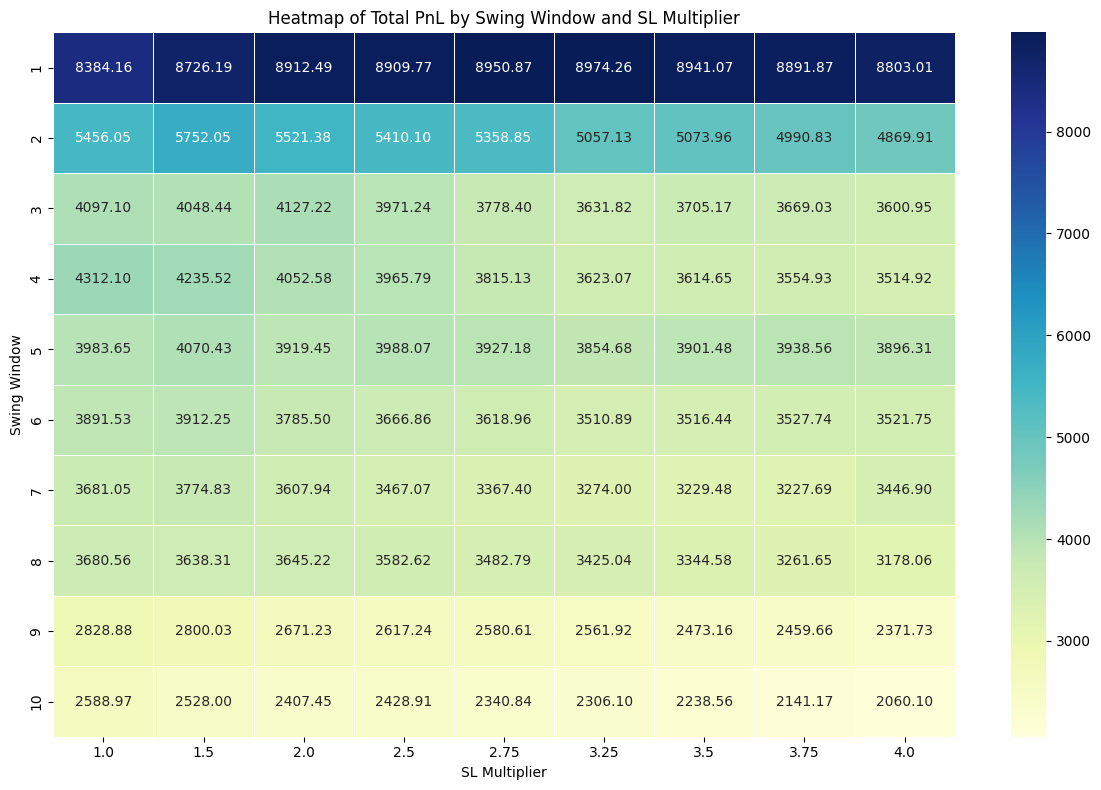

In [17]:
# Pivot the DataFrame to make it suitable for a heatmap
heatmap_data = df.pivot(index='Window', columns='SL Multiplier', values='Total PnL')

# Sort the axes for better readability
heatmap_data = heatmap_data.sort_index().sort_index(axis=1)

# Plot
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=.5)
plt.title("Heatmap of Total PnL by Swing Window and SL Multiplier")
plt.xlabel("SL Multiplier")
plt.ylabel("Swing Window")
plt.tight_layout()
plt.show()


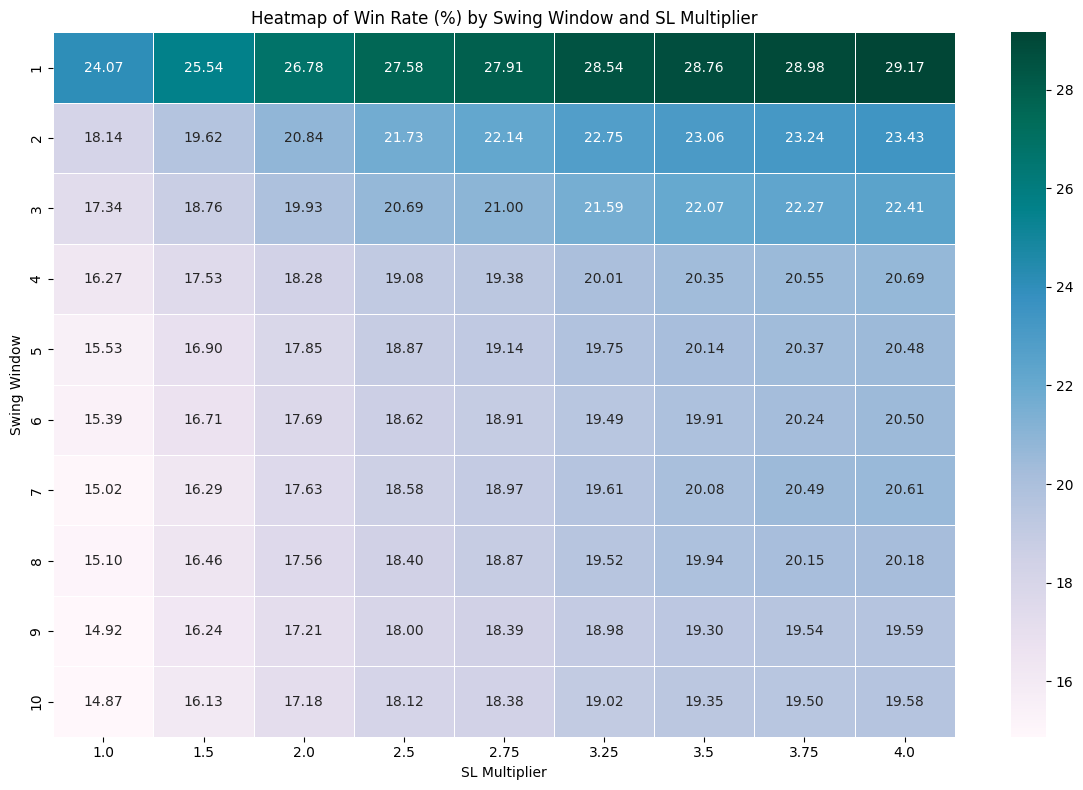

In [18]:
plt.figure(figsize=(12, 8))
win_rate_data = df.pivot(index='Window', columns='SL Multiplier', values='Win Rate (%)')
win_rate_data = win_rate_data.sort_index().sort_index(axis=1)
sns.heatmap(win_rate_data, annot=True, fmt=".2f", cmap="PuBuGn", linewidths=.5)
plt.title("Heatmap of Win Rate (%) by Swing Window and SL Multiplier")
plt.xlabel("SL Multiplier")
plt.ylabel("Swing Window")
plt.tight_layout()
plt.show()


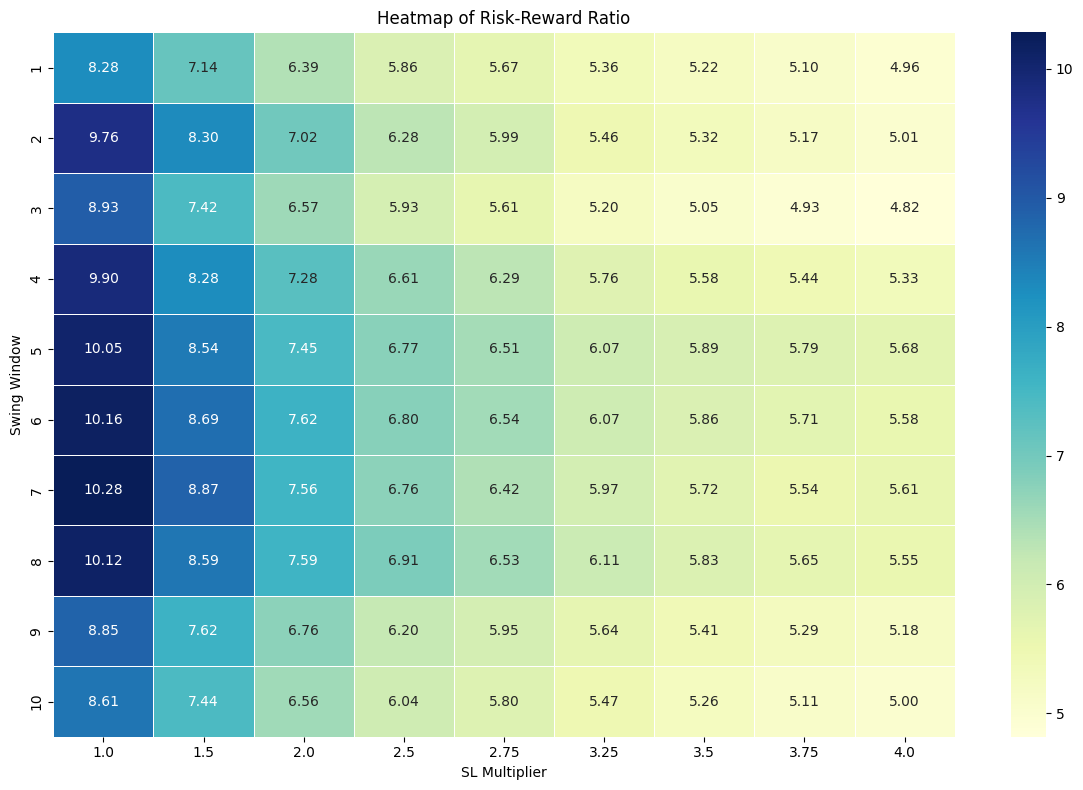

In [19]:
plt.figure(figsize=(12, 8))
rr_data = df.pivot(index='Window', columns='SL Multiplier', values='Risk-Reward')
rr_data = rr_data.sort_index().sort_index(axis=1)
sns.heatmap(rr_data, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=.5)
plt.title("Heatmap of Risk-Reward Ratio")
plt.xlabel("SL Multiplier")
plt.ylabel("Swing Window")
plt.tight_layout()
plt.show()


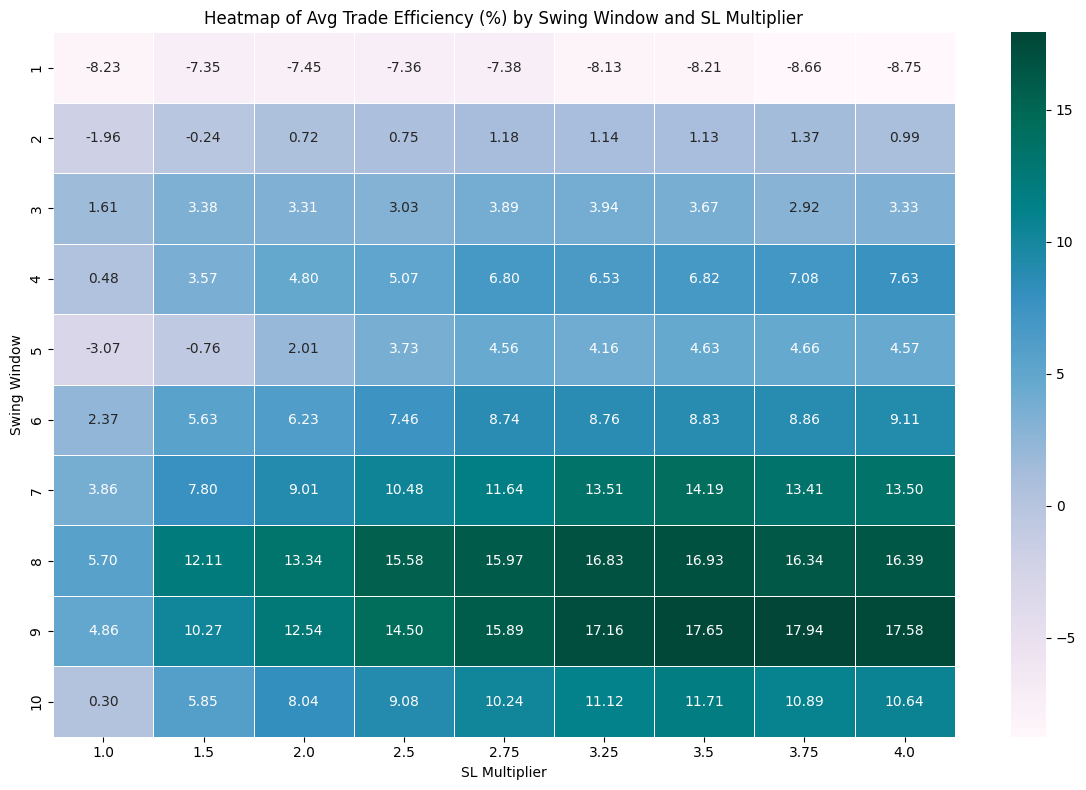

In [20]:
plt.figure(figsize=(12, 8))
win_rate_data = df.pivot(index='Window', columns='SL Multiplier', values='Avg Trade Efficiency (%)')
win_rate_data = win_rate_data.sort_index().sort_index(axis=1)
sns.heatmap(win_rate_data, annot=True, fmt=".2f", cmap="PuBuGn", linewidths=.5)
plt.title("Heatmap of Avg Trade Efficiency (%) by Swing Window and SL Multiplier")
plt.xlabel("SL Multiplier")
plt.ylabel("Swing Window")
plt.tight_layout()
plt.show()


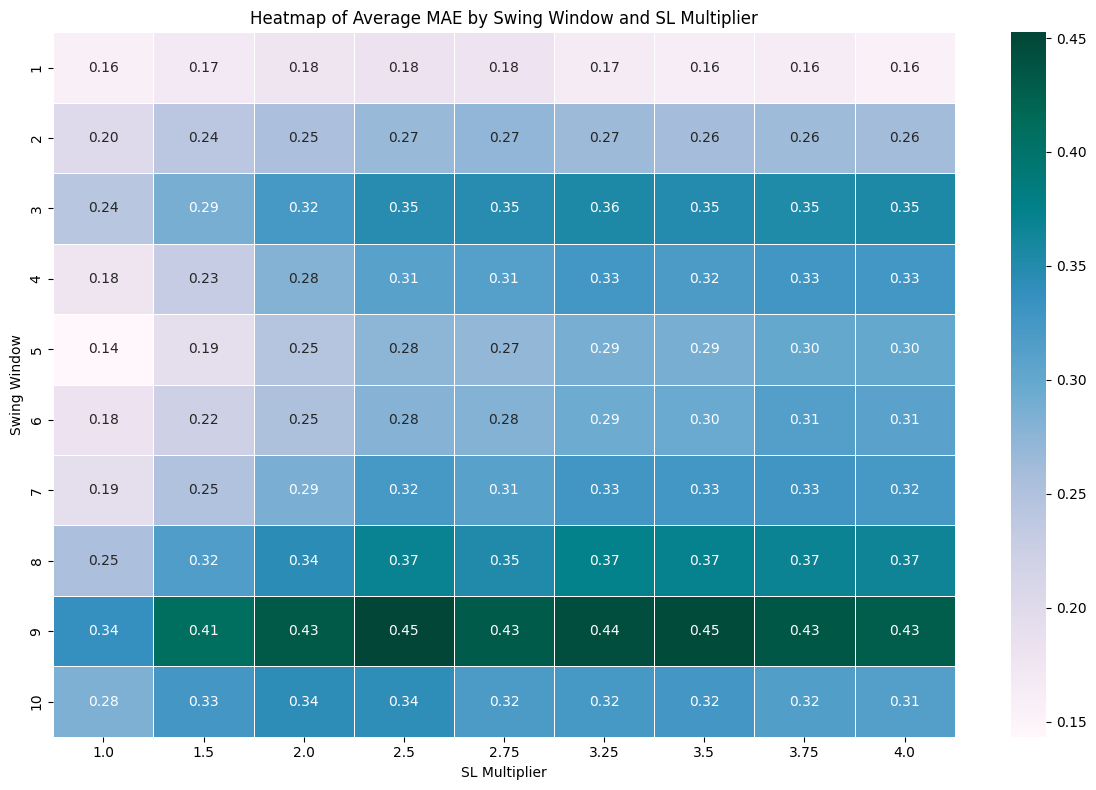

In [21]:
plt.figure(figsize=(12, 8))
win_rate_data = df.pivot(index='Window', columns='SL Multiplier', values='Average MAE')
win_rate_data = win_rate_data.sort_index().sort_index(axis=1)
sns.heatmap(win_rate_data, annot=True, fmt=".2f", cmap="PuBuGn", linewidths=.5)
plt.title("Heatmap of Average MAE by Swing Window and SL Multiplier")
plt.xlabel("SL Multiplier")
plt.ylabel("Swing Window")
plt.tight_layout()
plt.show()


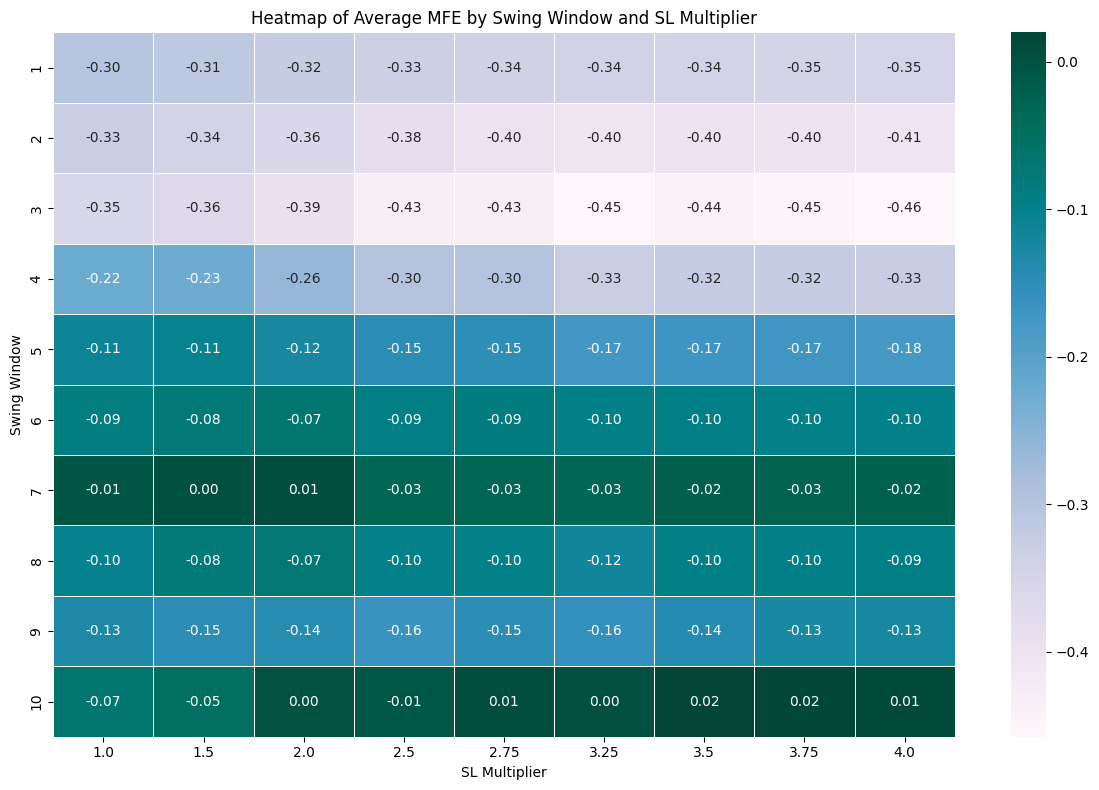

In [22]:
plt.figure(figsize=(12, 8))
win_rate_data = df.pivot(index='Window', columns='SL Multiplier', values='Average MFE')
win_rate_data = win_rate_data.sort_index().sort_index(axis=1)
sns.heatmap(win_rate_data, annot=True, fmt=".2f", cmap="PuBuGn", linewidths=.5)
plt.title("Heatmap of Average MFE by Swing Window and SL Multiplier")
plt.xlabel("SL Multiplier")
plt.ylabel("Swing Window")
plt.tight_layout()
plt.show()


C:\Users\A\AppData\Local\Temp\ipykernel_104160\3756830506.py:46: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\A\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


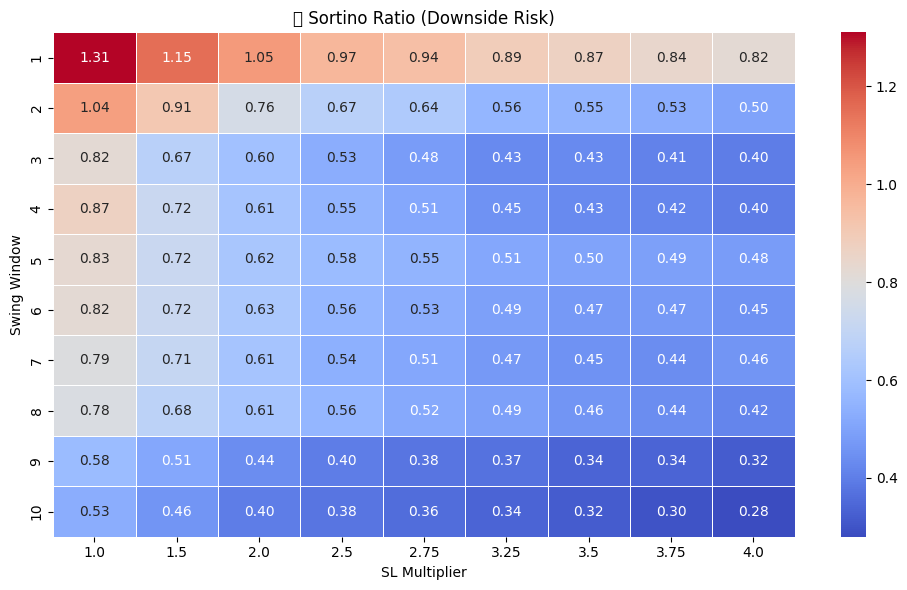

C:\Users\A\AppData\Local\Temp\ipykernel_104160\3756830506.py:46: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\A\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


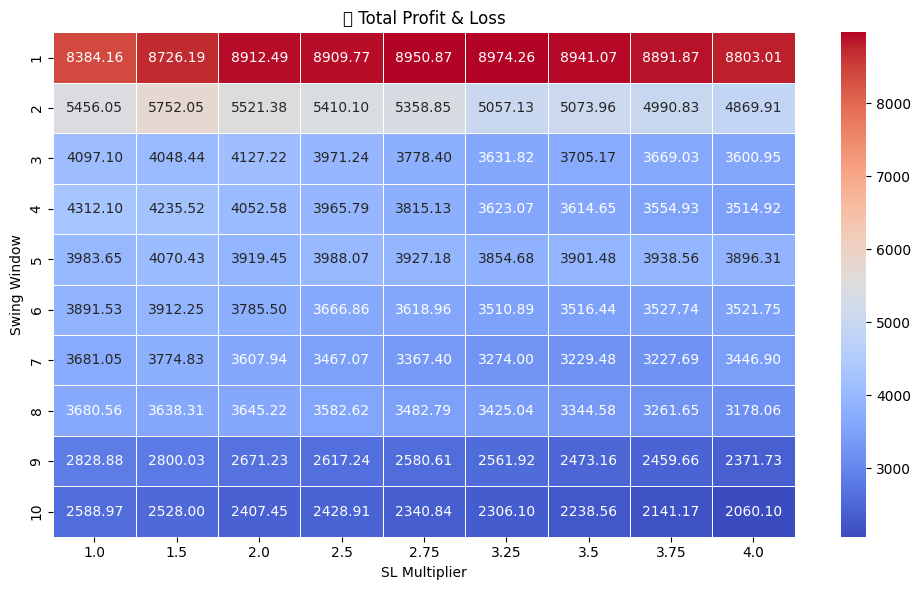

C:\Users\A\AppData\Local\Temp\ipykernel_104160\3756830506.py:46: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\A\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


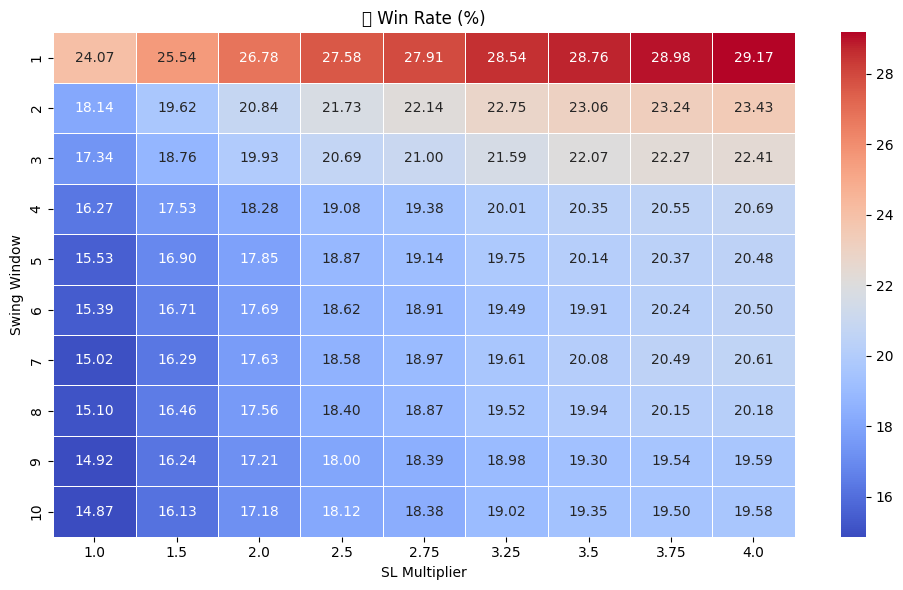

C:\Users\A\AppData\Local\Temp\ipykernel_104160\3756830506.py:46: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\A\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


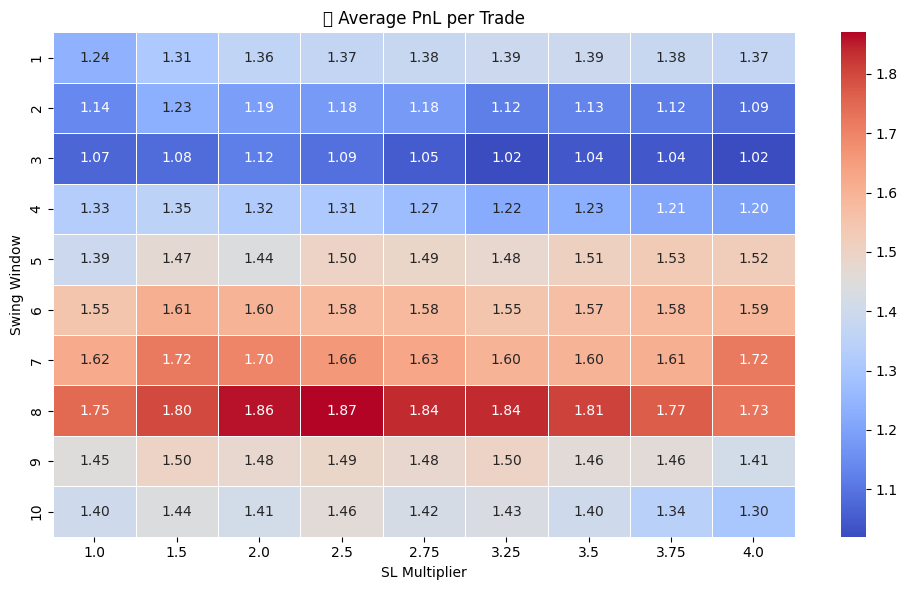

C:\Users\A\AppData\Local\Temp\ipykernel_104160\3756830506.py:46: UserWarning: Glyph 128315 (\N{DOWN-POINTING RED TRIANGLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\A\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128315 (\N{DOWN-POINTING RED TRIANGLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


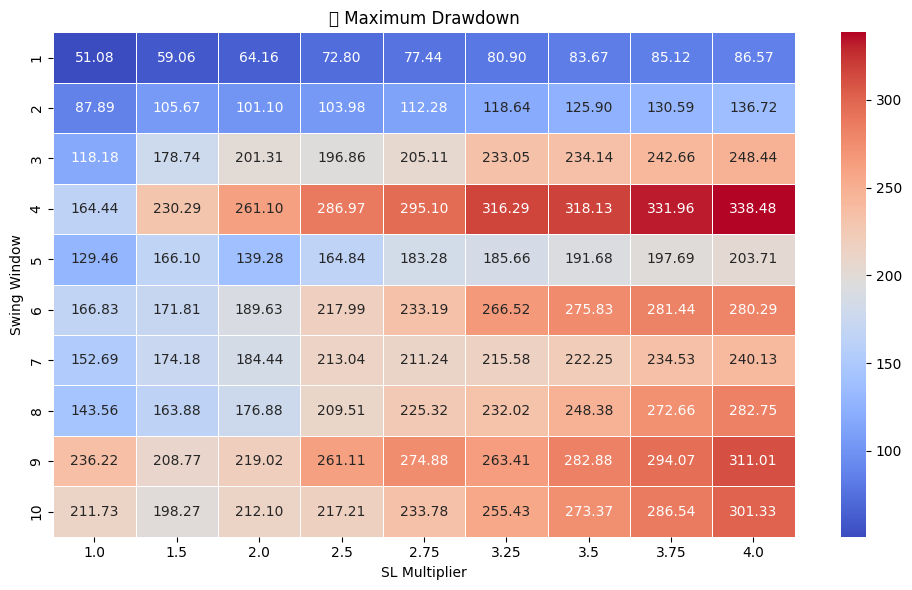

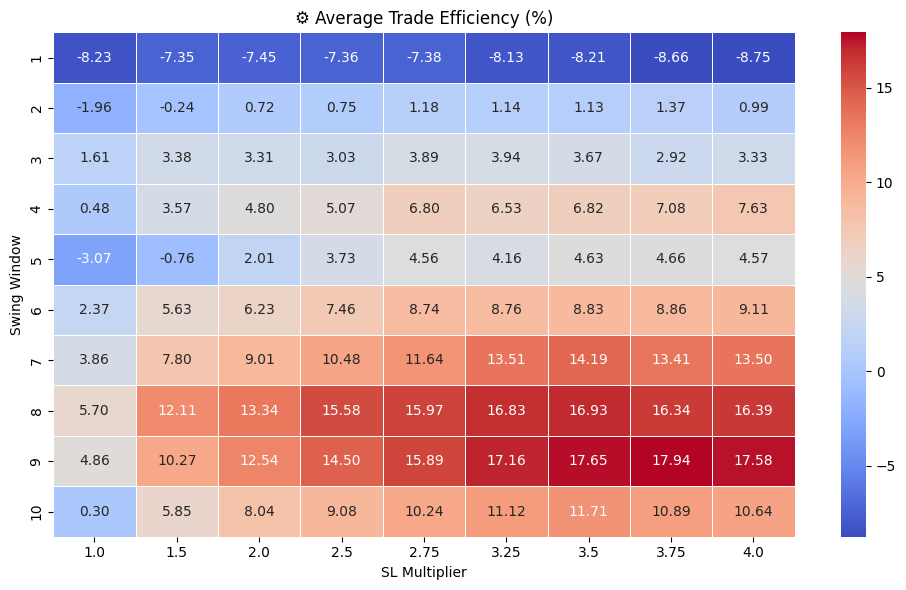

C:\Users\A\AppData\Local\Temp\ipykernel_104160\3756830506.py:46: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\A\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


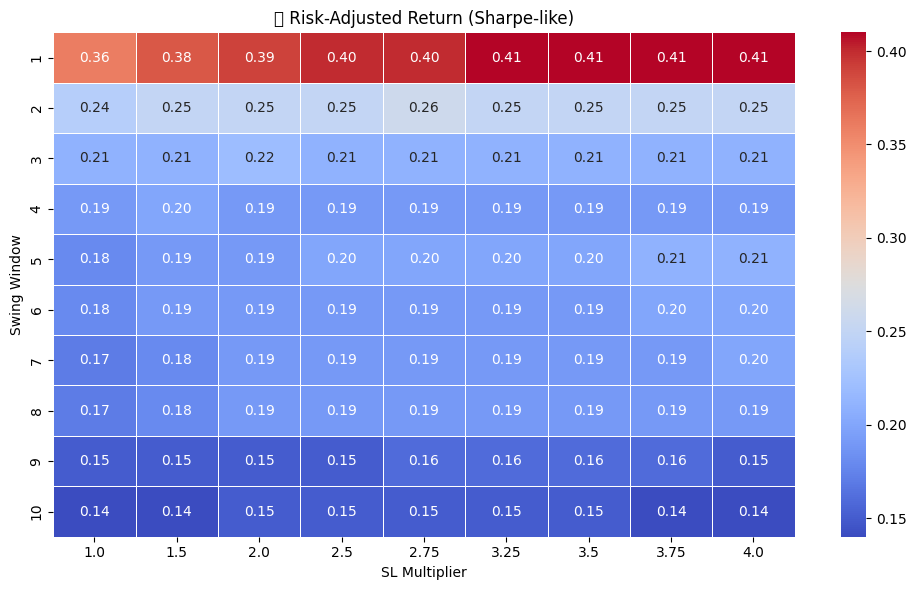

C:\Users\A\AppData\Local\Temp\ipykernel_104160\3756830506.py:46: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\A\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


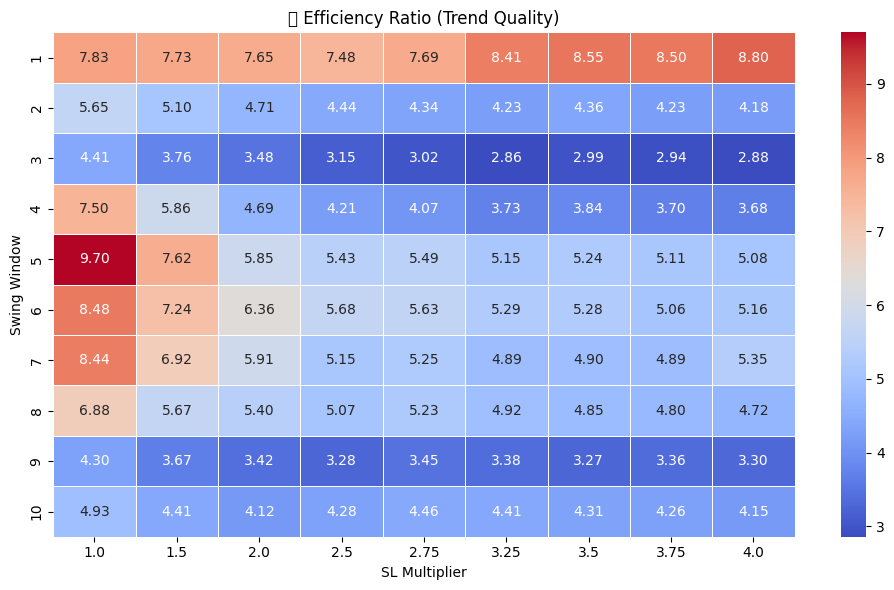

In [23]:
import numpy as np

# Replace 0 standard deviation to avoid division errors
def safe_divide(a, b):
    return a / b if b != 0 else np.nan

# Add new metrics
df["Sharpe-like Ratio"] = df.apply(
    lambda row: safe_divide(row["Average PnL"], np.std([row["Avg Win"], abs(row["Avg Loss"])])),
    axis=1
)

df["Expectancy"] = df["Win Rate (%)"] / 100 * df["Avg Win"] + (1 - df["Win Rate (%)"] / 100) * df["Avg Loss"]

df["Normalized PnL"] = df["Total PnL"] / df["Total Trades"]

df["PnL per Unit"] = df["Total PnL"] / (df["Units"] if "Units" in df.columns else df["Total Trades"])

df["Efficiency Ratio"] = df.apply(
    lambda row: safe_divide(row["Average PnL"], abs(row["Average MAE"])), axis=1
)

# Optional: Round floats for clean visuals
df = df.round(2)

# Define the metric columns and titles for heatmaps
metrics_titles = [
    ("Sortino Ratio", "📉 Sortino Ratio (Downside Risk)"),
    ("Total PnL", "🟢 Total Profit & Loss"),
    ("Win Rate (%)", "🏆 Win Rate (%)"),
    ("Average PnL", "📈 Average PnL per Trade"),
    ("Max Drawdown", "🔻 Maximum Drawdown"),
    ("Avg Trade Efficiency (%)", "⚙️ Average Trade Efficiency (%)"),
    ("Sharpe-like Ratio", "📊 Risk-Adjusted Return (Sharpe-like)"),
    ("Efficiency Ratio", "📈 Efficiency Ratio (Trend Quality)")# You must have this column precomputed
]

# Function to plot a single heatmap
def plot_heatmap(metric, title, cmap='coolwarm', fmt='.2f'):
    pivot = df.pivot(index="Window", columns="SL Multiplier", values=metric)
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap, linewidths=0.5)
    plt.title(title)
    plt.xlabel("SL Multiplier")
    plt.ylabel("Swing Window")
    plt.tight_layout()
    plt.show()

# Plot all six heatmaps
for metric, title in metrics_titles:
    plot_heatmap(metric, title)


In [13]:
df.columns

Index(['Window', 'SL Multiplier', 'Total Trades', 'Total Units',
       'Win Rate (%)', 'Total PnL', 'Average PnL', 'Max Drawdown',
       'Risk-Reward', 'Avg Win', 'Avg Loss', 'Average MAE', 'Max MAE',
       'Average MFE', 'Max MFE', 'Winning PnL', 'Losing PnL',
       'Avg Trade Efficiency (%)', 'Sharpe-like Ratio', 'Expectancy',
       'Normalized PnL', 'PnL per Unit', 'Efficiency Ratio', 'Sortino Ratio'],
      dtype='object')

In [14]:
df['Sortino Ratio']

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
      ..
85   NaN
86   NaN
87   NaN
88   NaN
89   NaN
Name: Sortino Ratio, Length: 90, dtype: float64